In [1]:
# --- Core libs ---
import os
import re
import glob
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy.stats as stats

# Optional plotting niceties (safe to keep; you can remove if you want)
import seaborn as sns
sns.set_theme(style="whitegrid")

# --- Reproducibility ---
seed = 42
np.random.seed(seed)
random.seed(seed)

# --- Paths helper (LUCAS non-linear setup) ---
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
PACK_PATH = os.path.join(BASE_DIR, "lucas_pack.pkl")
RESULTS_DIR = os.path.join(BASE_DIR, "results_nonlinear")
EVAL_DIR = os.path.join(BASE_DIR, "evaluation_results")

print("✅ Imports ready.")
print("PACK_PATH:", PACK_PATH)
print("RESULTS_DIR:", RESULTS_DIR)
print("EVAL_DIR:", EVAL_DIR)


✅ Imports ready.
PACK_PATH: data/lucas/lucas_pack.pkl
RESULTS_DIR: data/lucas/results_nonlinear
EVAL_DIR: data/lucas/evaluation_results


In [12]:
# ------------------------------------------------------------
# Label maps for nonlinear LUCAS empirical evaluation
# ------------------------------------------------------------

label_map_empirical = {
    'DiRoCA (eps_0.5_delta_0.5)': 'DiRoCA_star',
    'DiRoCA (eps_1.0_delta_1.0)': 'DIROCA_1',
    'DiRoCA (eps_2.0_delta_2.0)': 'DIROCA_2',
    'DiRoCA (eps_4.0_delta_4.0)': 'DIROCA_4',
    'DiRoCA (eps_8.0_delta_8.0)': 'DIROCA_8',
    'GradCA': 'GradCA',
    'BaryCA': 'BARYCA',
    'Abs-LiNGAM (Perfect)': 'Abslin_p',
    'Abs-LiNGAM (Noisy)': 'Abslin_n'
}


# Pretty-print labels for plots
print_label_map = {
    "DIROCA_0.5" : r"DiRoCA$_{0.5,0.5}$",
    "DIROCA_1"   : r"DiRoCA$_{1,1}$",
    "DIROCA_2"   : r"DiRoCA$_{2,2}$",
    "DIROCA_4"   : r"DiRoCA$_{4,4}$",
    "DIROCA_8"   : r"DiRoCA$_{8,8}$",

    "GradCA" : r"GRAD$_{(\tau, \omega)}$",
    "BARYCA" : r"BARY$_{(\tau, \omega)}$",

    "Abslin_p": r"AbsLin$_{\text{p}}$",
    "Abslin_n": r"AbsLin$_{\text{n}}$",
}

print("Label maps ready.")


Label maps ready.


In [13]:
# ------------------------------------------------------------
# Generic loader for empirical evaluation CSVs (any experiment)
# ------------------------------------------------------------

def load_empirical_results(experiment, distribution, shift_type="additive"):
    """
    Load the latest empirical evaluation CSV for a given experiment + distribution.
    
    Expected directory:
        data/{experiment}/evaluation_results/

    Expected filename prefix:
        empirical_evaluation_{shift_type}_{distribution}_...

    Returns:
        pd.DataFrame or None
    """
    eval_dir = os.path.join("data", experiment, "evaluation_results")
    if not os.path.exists(eval_dir):
        print(f"[WARN] Evaluation directory not found: {eval_dir}")
        return None

    pattern = f"empirical_evaluation_{shift_type}_{distribution}_*.csv"
    files = sorted(glob.glob(os.path.join(eval_dir, pattern)))

    if len(files) == 0:
        print(f"[WARN] No evaluation file matching: {os.path.join(eval_dir, pattern)}")
        return None

    latest = files[-1]  # newest by lexicographic timestamp suffix
    print(f"[LOAD] {experiment} / {distribution} -> {latest}")

    try:
        return pd.read_csv(latest)
    except Exception as e:
        print(f"[ERROR] Could not load {latest}: {e}")
        return None


[LOAD] lucas / gaussian -> data/lucas/evaluation_results/empirical_evaluation_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251121_111429.csv
[LOAD] lucas / student-t -> data/lucas/evaluation_results/empirical_evaluation_additive_student-t_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251121_115932.csv
[LOAD] lucas / exponential -> data/lucas/evaluation_results/empirical_evaluation_additive_exponential_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251121_122611.csv


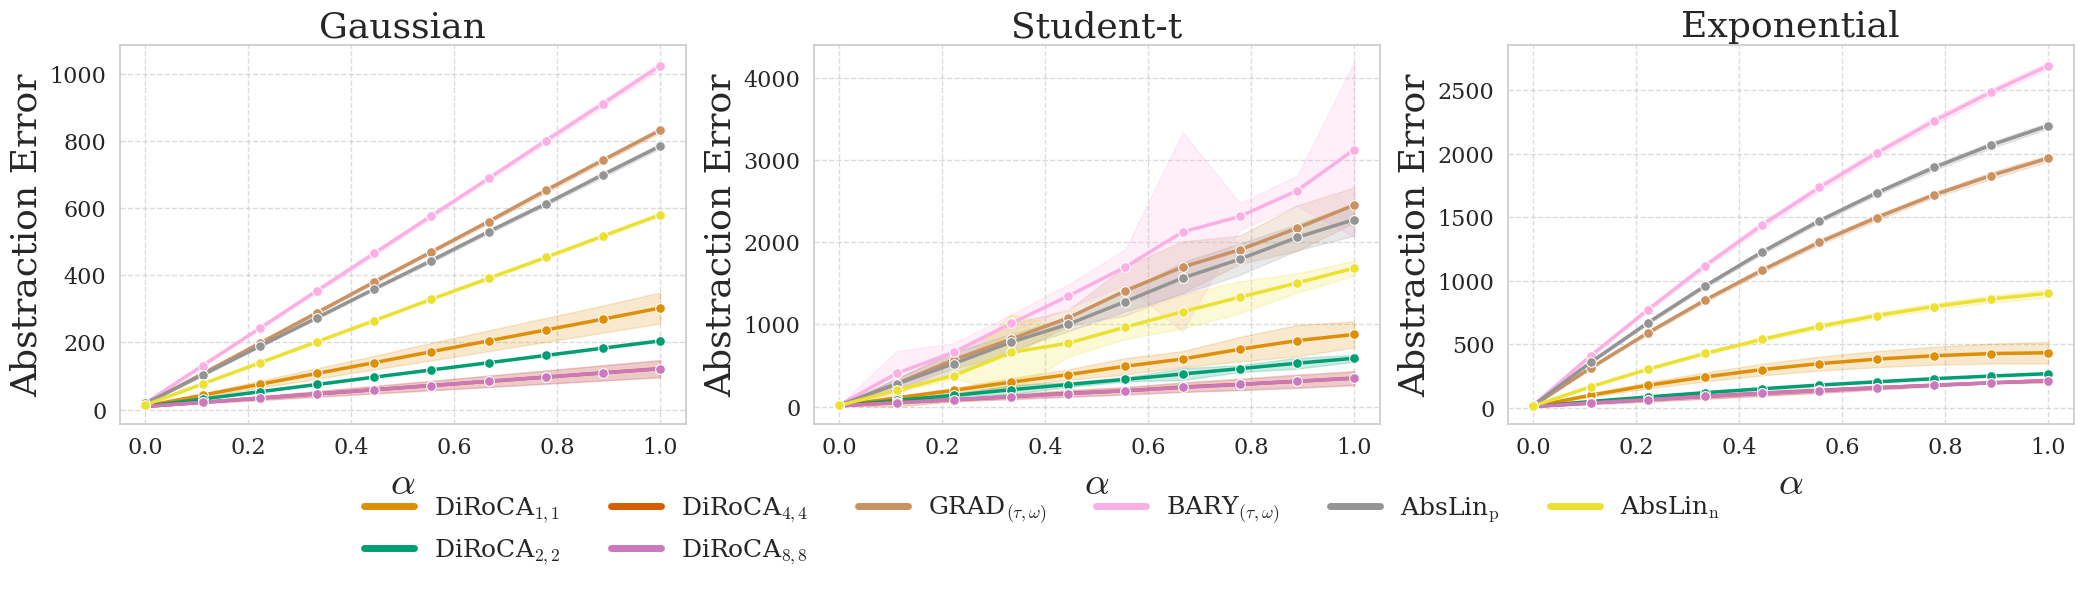

In [14]:
# ------------------------------------------------------------
# Plot abstraction error vs alpha for NONLINEAR LUCAS
# 3 panels: Gaussian / Student-t / Exponential (additive Huber)
# ------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif"
})

experiment = "lucas"

# Methods we actually have in LUCAS runs (from your label_map above)
methods_to_plot = [
    "DIROCA_0.5", "DIROCA_1", "DIROCA_2", "DIROCA_4", "DIROCA_8",
    "GradCA", "BARYCA", "Abslin_p", "Abslin_n"
]
display_names = [print_label_map[m] for m in methods_to_plot]

# Color palette (consistent across panels)
palette_colors = sns.color_palette("colorblind", n_colors=len(display_names))
color_map = dict(zip(display_names, palette_colors))

# (optional) override a few colors if you want them fixed:
# color_map.update({
#     r"DiRoCA$_{0.5,0.5}$": "#1f77b4",
#     r"DiRoCA$_{1,1}$": "gold",
#     r"DiRoCA$_{2,2}$": "darkorange",
#     r"DiRoCA$_{4,4}$": "lightskyblue",
#     r"DiRoCA$_{8,8}$": "violet",
#     r"GRAD$_{(\tau, \omega)}$": "#2ca02c",
#     r"BARY$_{(\tau, \omega)}$": "#d62728",
#     r"AbsLin$_{\\text{p}}$": "#9467bd",
#     r"AbsLin$_{\\text{n}}$": "#8c564b",
# })

# Fixed noise level for lucas plots (matches your eval batch: noise_max=10)
noise_level_to_plot = 10.0

# Panels = contamination distributions
panels = [
    ("gaussian",  "Gaussian"),
    ("student-t", "Student-t"),
    ("exponential","Exponential"),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)
fig.subplots_adjust(wspace=0.35)

combined_handles = {}
present_display_names_global = set()

for ax, (dist, title_str) in zip(axes, panels):

    # Load evaluation results for this distribution
    df = load_empirical_results(experiment=experiment, distribution=dist)


    if df is None or df.empty:
        print(f"No data found for {experiment} / {dist}")
        ax.set_title(title_str, fontsize=26)
        ax.set_xlabel(r"$\alpha$", fontsize=28)
        ax.set_ylabel("Abstraction Error", fontsize=26)
        ax.grid(True, linestyle="--", alpha=0.7)
        continue

    # Rename methods using LUCAS label map
    df["method"] = df["method"].replace(label_map_empirical)

    # Filter to a single noise level + methods of interest
    df = df[
        (df["noise_scale"] == noise_level_to_plot) &
        (df["method"].isin(methods_to_plot))
    ].copy()

    if df.empty:
        print(f"No filtered data for {experiment} / {dist}")
        ax.set_title(title_str, fontsize=26)
        ax.set_xlabel(r"$\alpha$", fontsize=28)
        ax.set_ylabel("Abstraction Error", fontsize=26)
        ax.grid(True, linestyle="--", alpha=0.7)
        continue

    df["display_name"] = df["method"].map(print_label_map)

    sns.lineplot(
        data=df,
        x="alpha",
        y="error",
        hue="display_name",
        hue_order=display_names,
        palette=color_map,
        marker="o",
        linewidth=2.5,
        markersize=7,
        errorbar="sd",
        ax=ax,
        legend=False
    )

    present_display_names_global.update(df["display_name"].unique())

    ax.set_title(title_str, fontsize=26)
    ax.set_xlabel(r"$\alpha$", fontsize=28)
    ax.set_ylabel("Abstraction Error", fontsize=26)
    ax.tick_params(axis="both", labelsize=16)
    ax.grid(True, linestyle="--", alpha=0.7)

    handles, labels = ax.get_legend_handles_labels()
    for h, l in zip(handles, labels):
        if l and (l not in combined_handles):
            combined_handles[l] = h

# Shared legend at bottom
present_display_names_ordered = [lbl for lbl in display_names if lbl in present_display_names_global]

if present_display_names_ordered:
    ordered_handles = [
        plt.Line2D([], [], linestyle="-", linewidth=5,
                   label=lbl, color=color_map.get(lbl, "#000000"))
        for lbl in present_display_names_ordered
    ]
    fig.legend(
        ordered_handles,
        present_display_names_ordered,
        loc="lower center",
        ncol=min(6, len(present_display_names_ordered)),
        fontsize=18,
        frameon=False
    )

fig.tight_layout(rect=[0, 0.12, 1, 1.0])

os.makedirs("plots", exist_ok=True)
plt.savefig("plots/abstraction_vs_alpha_LUCAS_1x3.png", dpi=300, bbox_inches="tight")
plt.show()


[LOAD] slc / gaussian -> data/slc/evaluation_results/empirical_evaluation_additive_gaussian_alpha5-0.0-1.0_noise5-0.0-5.0_trials2_zero_meanTrue_20250727_112728.csv
[LOAD] slc / student-t -> data/slc/evaluation_results/empirical_evaluation_additive_student-t_alpha10-0.0-1.0_noise20-0.0-5.0_trials20_zero_meanTrue_20250930_191641.csv
[LOAD] lilucas / gaussian -> data/lilucas/evaluation_results/empirical_evaluation_additive_gaussian_alpha10-0.0-1.0_noise20-0.0-10.0_trials20_zero_meanTrue_20250930_200124.csv
[LOAD] lilucas / student-t -> data/lilucas/evaluation_results/empirical_evaluation_additive_student-t_alpha10-0.0-1.0_noise20-0.0-10.0_trials20_zero_meanTrue_20250930_205000.csv


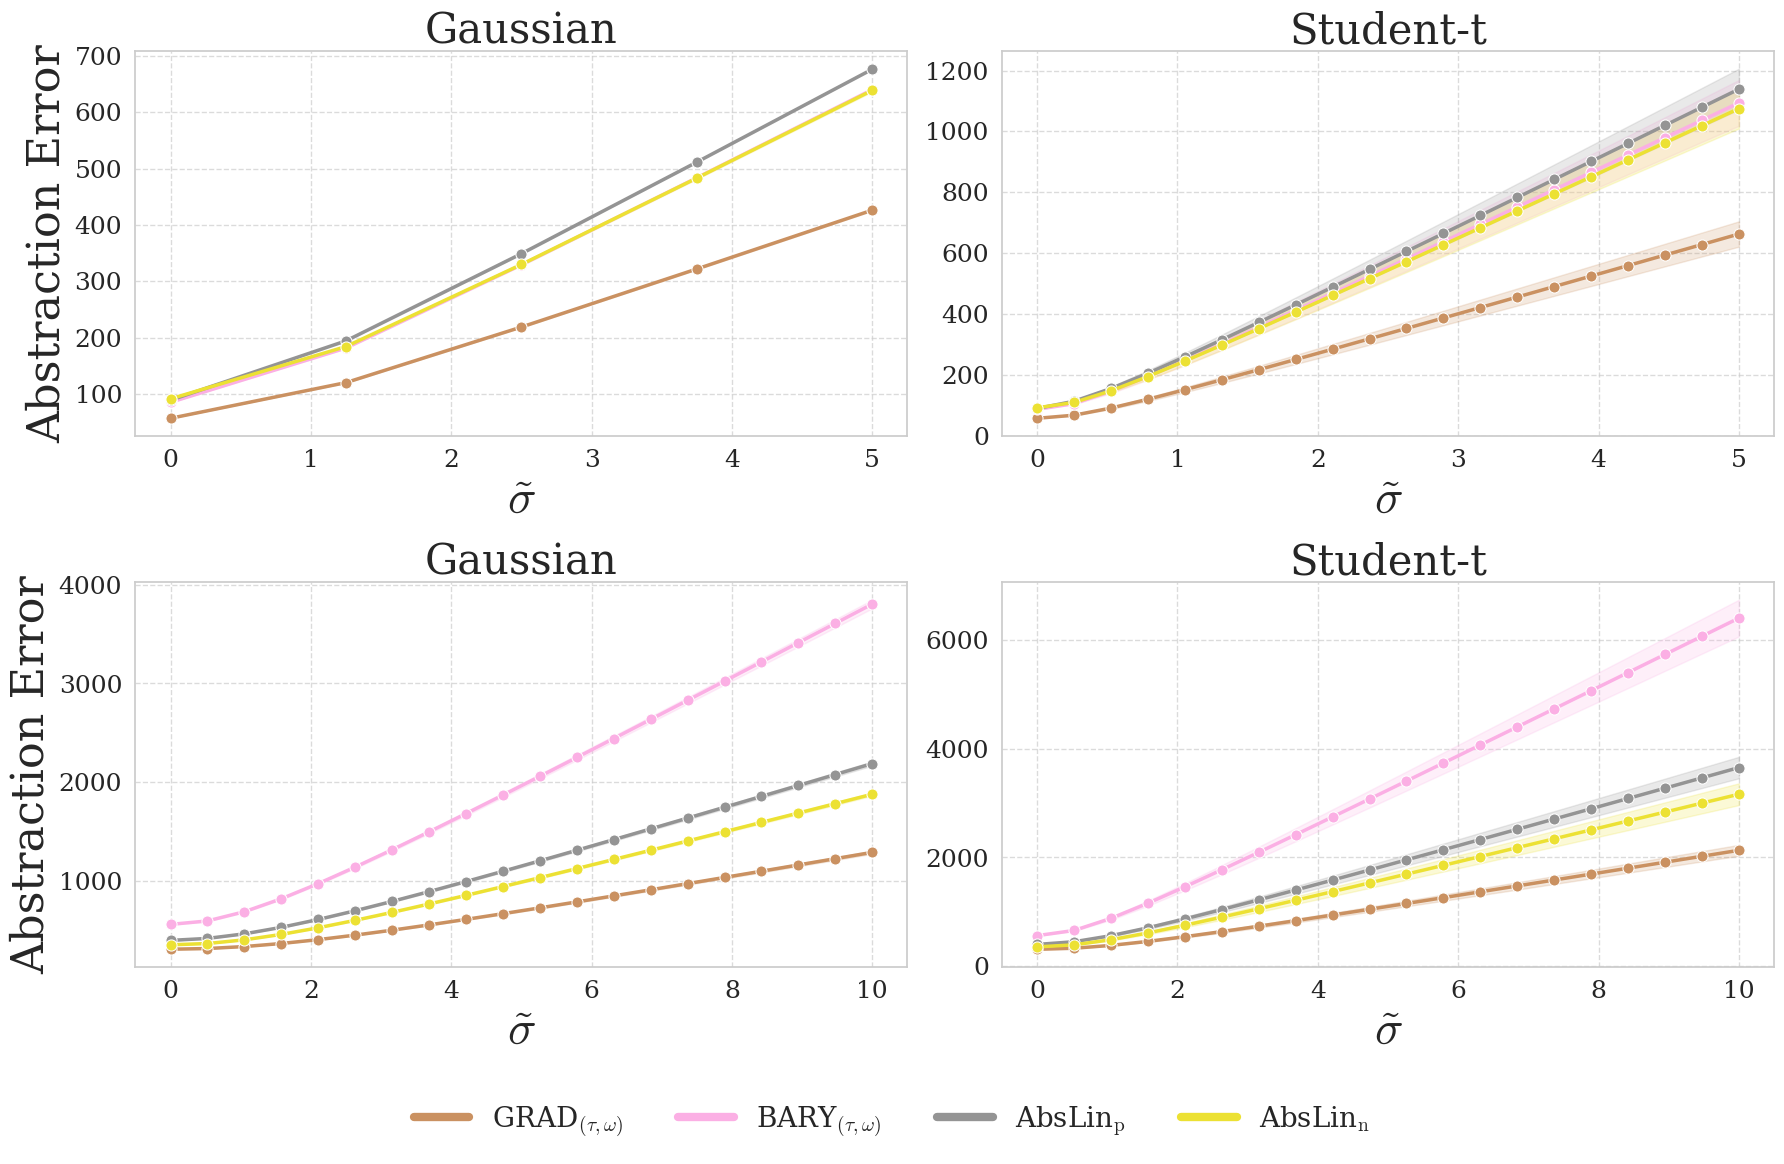

In [15]:
# ------------------------------------------------------------
# Plot abstraction error vs noise_scale at fixed alpha (generic)
# ------------------------------------------------------------

# Pick what alpha you want per experiment (edit/add experiments freely)
fixed_alpha_to_plot = {
    'slc': 1.0,
    'lilucas': 1.0,
    'lucas': 1.0,      # you can add more experiments later
    'battery': 1.0
}

# If you want to cap x-range by experiment, set max noise here
noise_level_to_plot = {
    'slc': 5.0,
    'lilucas': 10.0,
    'lucas': 10.0,     # matches your lucas batch
    'battery': 10.0
}

# Panels: (subplot position), experiment, distribution, title
panels = [
    ((0, 0), 'slc',     'gaussian',  "Gaussian"),
    ((0, 1), 'slc',     'student-t', "Student-t"),
    ((1, 0), 'lilucas', 'gaussian',  "Gaussian"),
    ((1, 1), 'lilucas', 'student-t', "Student-t"),
    # Example for lucas (uncomment if you want a lucas grid)
    # ((0, 0), 'lucas', 'gaussian',   "Gaussian"),
    # ((0, 1), 'lucas', 'student-t',  "Student-t"),
    # ((1, 0), 'lucas', 'exponential',"Exponential"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=False)
fig.subplots_adjust(hspace=0.4)

present_display_names_global = set()

for (r, c), experiment, dist, title_str in panels:
    ax = axes[r, c]

    # --- load latest CSV for this experiment + distribution ---
    df = load_empirical_results(experiment=experiment, distribution=dist)

    if df is None or df.empty:
        print(f"No data found for {experiment} / {dist}")
        ax.set_title(title_str, fontsize=30)
        ax.set_xlabel(r'$\tilde{\sigma}$', fontsize=34)
        ax.set_ylabel('Abstraction Error' if c == 0 else '', fontsize=32)
        ax.tick_params(axis='both', labelsize=18)
        ax.grid(True, linestyle='--', alpha=0.7)
        continue

    # --- auto-pick label map based on what methods look like ---
    # (lucas/battery style methods contain "eps_" and Abs-LiNGAM etc)
    df['method'] = df['method'].replace(label_map_empirical)


    # --- filter to fixed alpha + chosen methods ---
    a_star = fixed_alpha_to_plot.get(experiment, 1.0)
    df = df[
        (np.abs(df['alpha'] - a_star) < 1e-4) &
        (df['method'].isin(methods_to_plot))
    ].copy()

    if df.empty:
        print(f"No data for {experiment}/{dist} at alpha={a_star}")
        ax.set_title(title_str, fontsize=30)
        ax.set_xlabel(r'$\tilde{\sigma}$', fontsize=34)
        ax.set_ylabel('Abstraction Error' if c == 0 else '', fontsize=32)
        ax.tick_params(axis='both', labelsize=18)
        ax.grid(True, linestyle='--', alpha=0.7)
        continue

    df['display_name'] = df['method'].map(print_label_map)

    # Optionally cap to max noise for this experiment
    max_noise = noise_level_to_plot.get(experiment, None)
    if max_noise is not None:
        df = df[df['noise_scale'] <= max_noise]

    sns.lineplot(
        data=df,
        x='noise_scale',
        y='error',
        hue='display_name',
        hue_order=display_names,
        palette=color_map,
        marker='o',
        linewidth=2.5,
        markersize=8,
        errorbar='sd',
        ax=ax,
        legend=False
    )
    present_display_names_global.update(df['display_name'].unique())

    ax.set_title(title_str, fontsize=30)
    ax.set_xlabel(r'$\tilde{\sigma}$', fontsize=34)
    ax.set_ylabel('Abstraction Error' if c == 0 else '', fontsize=32)
    ax.tick_params(axis='both', labelsize=18)
    ax.grid(True, linestyle='--', alpha=0.7)

# --- shared legend ---
present_display_names_ordered = [lbl for lbl in display_names if lbl in present_display_names_global]

if present_display_names_ordered:
    ordered_handles = [
        plt.Line2D([], [], linestyle='-', linewidth=6,
                   label=lbl, color=color_map.get(lbl, '#000000'))
        for lbl in present_display_names_ordered
    ]
    fig.legend(
        ordered_handles,
        present_display_names_ordered,
        loc='lower center',
        ncol=min(6, len(present_display_names_ordered)),
        fontsize=20,
        frameon=False
    )
else:
    print("No legend entries found across panels; skipping legend.")

fig.tight_layout(rect=[0, 0.08, 1, 0.98])
plt.savefig("plots/abstraction_vs_noise_alpha_fixed_generic_2x2.png",
            dpi=300, bbox_inches='tight')
plt.show()


In [16]:
import os, glob, re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

sns.set_theme(style="whitegrid")

seed = 42
np.random.seed(seed)

# ------------------------------------------------------------
# Helper: load empirical evaluation CSVs for a given experiment
# ------------------------------------------------------------
def load_empirical_results(experiment: str, distribution: str):
    """
    Loads the most recent empirical evaluation CSV matching:
      data/{experiment}/evaluation_results/empirical_evaluation_additive_{distribution}_*.csv
    
    Returns a pandas DataFrame or None if not found.
    """
    eval_dir = os.path.join("data", experiment, "evaluation_results")
    pattern = os.path.join(eval_dir, f"empirical_evaluation_additive_{distribution}_*.csv")
    files = sorted(glob.glob(pattern))
    
    if len(files) == 0:
        print(f"[WARN] No empirical CSV found for {experiment} / {distribution}")
        return None
    
    # take the most recent one (sorted by name timestamp)
    path = files[-1]
    print(f"[LOAD] {distribution}: {path}")
    return pd.read_csv(path)


In [17]:
# ----------------------------
# LUCAS empirical label map
# ----------------------------
label_map_empirical = {
    "DiRoCA (eps_0.5_delta_0.5)": "DIROCA_0.5",
    "DiRoCA (eps_1.0_delta_1.0)": "DIROCA_1",
    "DiRoCA (eps_2.0_delta_2.0)": "DIROCA_2",
    "DiRoCA (eps_4.0_delta_4.0)": "DIROCA_4",
    "DiRoCA (eps_8.0_delta_8.0)": "DIROCA_8",
    "GradCA": "GradCA",
    "BaryCA": "BARYCA",
    "Abs-LiNGAM (Perfect)": "Abslin_p",
    "Abs-LiNGAM (Noisy)": "Abslin_n",
}

print_label_map = {
    "DIROCA_0.5": r"DiRoCA$_{0.5,0.5}$",
    "DIROCA_1":   r"DiRoCA$_{1,1}$",
    "DIROCA_2":   r"DiRoCA$_{2,2}$",
    "DIROCA_4":   r"DiRoCA$_{4,4}$",
    "DIROCA_8":   r"DiRoCA$_{8,8}$",
    "GradCA":     r"GRAD$_{(\tau,\omega)}$",
    "BARYCA":     r"BARY$_{(\tau,\omega)}$",
    "Abslin_p":   r"AbsLin$_{\text{p}}$",
    "Abslin_n":   r"AbsLin$_{\text{n}}$",
}

methods_to_plot = [
    "DIROCA_0.5", "DIROCA_1", "DIROCA_2", "DIROCA_4", "DIROCA_8",
    "GradCA", "BARYCA", "Abslin_p", "Abslin_n"
]
display_names = [print_label_map[m] for m in methods_to_plot]

# Color map (you can tweak)
palette_colors = sns.color_palette("colorblind", n_colors=len(display_names))
color_map = dict(zip(display_names, palette_colors))
color_map.update({
    r"DiRoCA$_{0.5,0.5}$": "#1f77b4",
    r"DiRoCA$_{1,1}$": "gold",
    r"DiRoCA$_{2,2}$": "darkorange",
    r"DiRoCA$_{4,4}$": "lightskyblue",
    r"DiRoCA$_{8,8}$": "violet",
    r"GRAD$_{(\tau,\omega)}$": "#2ca02c",
    r"BARY$_{(\tau,\omega)}$": "#d62728",
    r"AbsLin$_{\text{p}}$": "#9467bd",
    r"AbsLin$_{\text{n}}$": "#8c564b",
})


[LOAD] gaussian: data/lucas/evaluation_results/empirical_evaluation_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251121_111429.csv
[LOAD] student-t: data/lucas/evaluation_results/empirical_evaluation_additive_student-t_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251121_115932.csv
[LOAD] exponential: data/lucas/evaluation_results/empirical_evaluation_additive_exponential_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251121_122611.csv


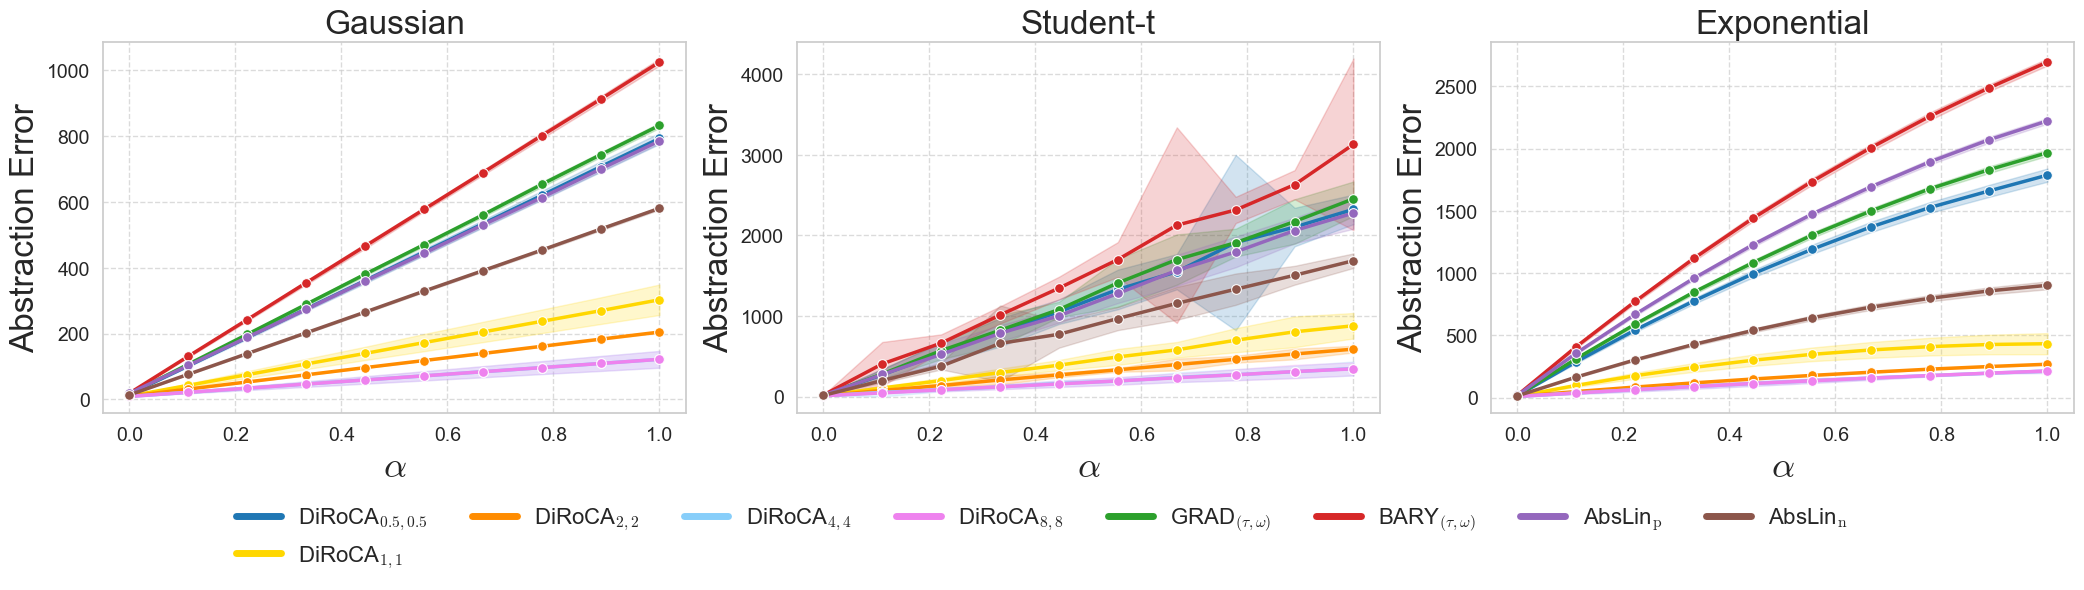

In [18]:
# ------------------------------------------------------------
# Plot abstraction error vs alpha for LUCAS (empirical only)
# Fix sigma tilde (noise_scale), vary alpha
# 3 panels: Gaussian / Student-t / Exponential
# ------------------------------------------------------------

experiment = "lucas"
fixed_sigma = 10.0   # you used noise_max=10 in your batch

panels = [
    ("gaussian",   "Gaussian"),
    ("student-t",  "Student-t"),
    ("exponential","Exponential"),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)
fig.subplots_adjust(wspace=0.35)

present_display_names_global = set()

for ax, (dist, title_str) in zip(axes, panels):
    
    df = load_empirical_results(experiment, dist)
    if df is None or df.empty:
        ax.set_title(title_str, fontsize=24)
        ax.set_xlabel(r"$\alpha$", fontsize=26)
        ax.set_ylabel("Abstraction Error", fontsize=24)
        ax.grid(True, linestyle="--", alpha=0.7)
        continue
    
    # map raw method names -> canonical short method ids
    df["method"] = df["method"].replace(label_map_empirical)

    # fix sigma and filter methods
    df = df[
        (np.abs(df["noise_scale"] - fixed_sigma) < 1e-6) &
        (df["method"].isin(methods_to_plot))
    ].copy()

    if df.empty:
        print(f"[WARN] No data after filtering for {dist}")
        continue

    df["display_name"] = df["method"].map(print_label_map)

    sns.lineplot(
        data=df,
        x="alpha",
        y="error",
        hue="display_name",
        hue_order=display_names,
        palette=color_map,
        marker="o",
        linewidth=2.5,
        markersize=7,
        errorbar="sd",
        ax=ax,
        legend=False,
    )

    present_display_names_global.update(df["display_name"].unique())

    ax.set_title(title_str, fontsize=24)
    ax.set_xlabel(r"$\alpha$", fontsize=26)
    ax.set_ylabel("Abstraction Error", fontsize=24)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, linestyle="--", alpha=0.7)

# shared legend
present_display_names_ordered = [lbl for lbl in display_names if lbl in present_display_names_global]
if present_display_names_ordered:
    ordered_handles = [
        plt.Line2D([], [], linestyle="-", linewidth=5,
                   label=lbl, color=color_map.get(lbl, "#000000"))
        for lbl in present_display_names_ordered
    ]
    fig.legend(
        ordered_handles,
        present_display_names_ordered,
        loc="lower center",
        ncol=min(8, len(present_display_names_ordered)),
        fontsize=16,
        frameon=False
    )

fig.tight_layout(rect=[0, 0.15, 1, 1.0])
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/abstraction_vs_alpha_LUCAS_1x3.png", dpi=300, bbox_inches="tight")
plt.show()


[LOAD] gaussian: data/lucas/evaluation_results/empirical_evaluation_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251121_111429.csv
[LOAD] student-t: data/lucas/evaluation_results/empirical_evaluation_additive_student-t_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251121_115932.csv
[LOAD] exponential: data/lucas/evaluation_results/empirical_evaluation_additive_exponential_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251121_122611.csv


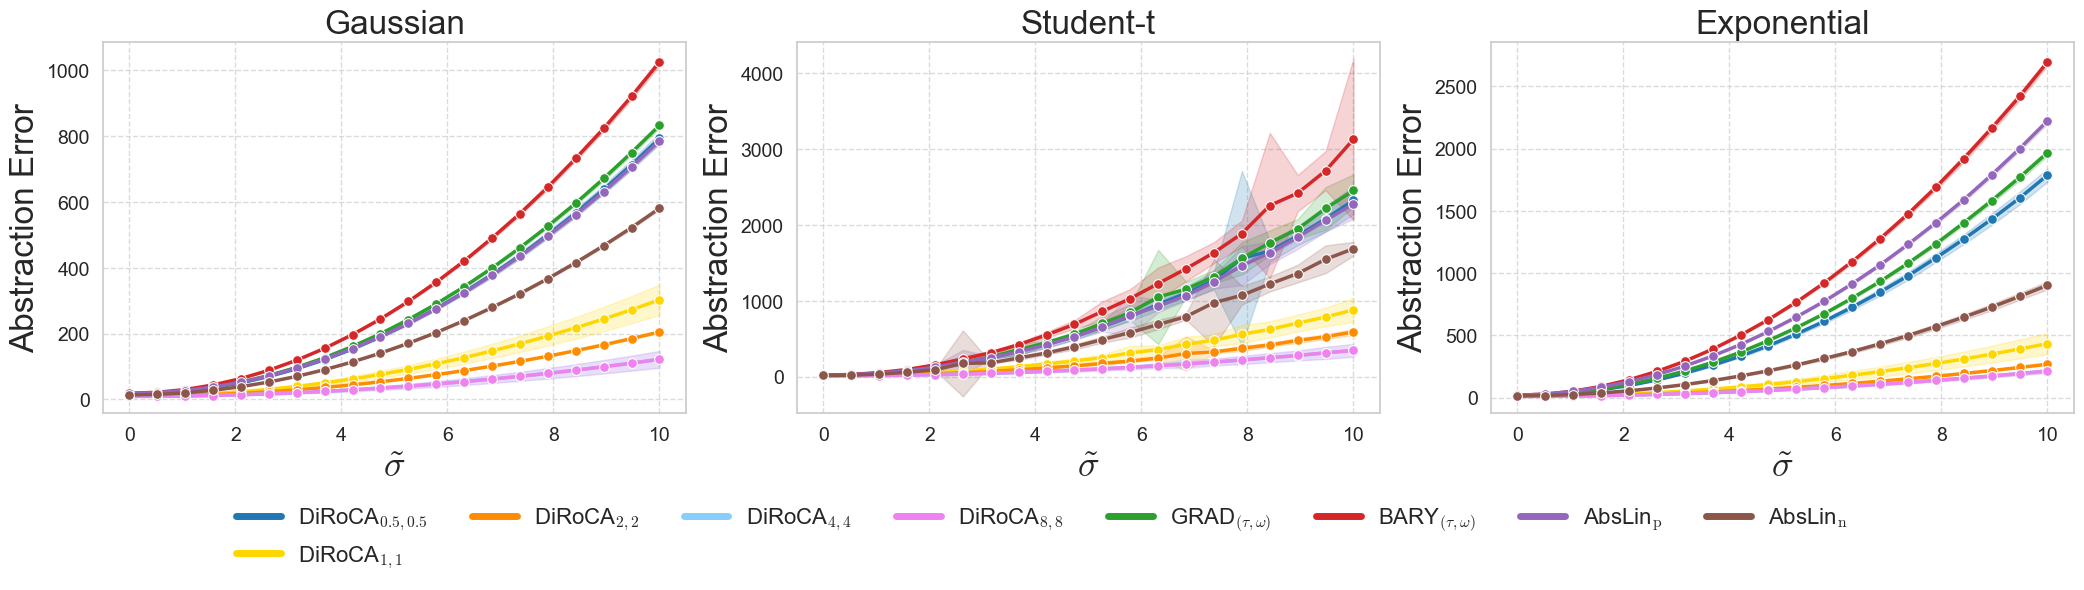

In [19]:
# ------------------------------------------------------------
# Plot abstraction error vs noise_scale (σ̃) for LUCAS
# Fix alpha, vary sigma tilde
# 3 panels: Gaussian / Student-t / Exponential
# ------------------------------------------------------------

experiment = "lucas"
fixed_alpha = 1.0

panels = [
    ("gaussian",   "Gaussian"),
    ("student-t",  "Student-t"),
    ("exponential","Exponential"),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)
fig.subplots_adjust(wspace=0.35)

present_display_names_global = set()

for ax, (dist, title_str) in zip(axes, panels):
    
    df = load_empirical_results(experiment, dist)
    if df is None or df.empty:
        ax.set_title(title_str, fontsize=24)
        ax.set_xlabel(r"$\tilde{\sigma}$", fontsize=26)
        ax.set_ylabel("Abstraction Error", fontsize=24)
        ax.grid(True, linestyle="--", alpha=0.7)
        continue
    
    df["method"] = df["method"].replace(label_map_empirical)

    # fix alpha and filter methods
    df = df[
        (np.abs(df["alpha"] - fixed_alpha) < 1e-6) &
        (df["method"].isin(methods_to_plot))
    ].copy()

    if df.empty:
        print(f"[WARN] No data after filtering for {dist}")
        continue

    df["display_name"] = df["method"].map(print_label_map)

    sns.lineplot(
        data=df,
        x="noise_scale",
        y="error",
        hue="display_name",
        hue_order=display_names,
        palette=color_map,
        marker="o",
        linewidth=2.5,
        markersize=7,
        errorbar="sd",
        ax=ax,
        legend=False,
    )

    present_display_names_global.update(df["display_name"].unique())

    ax.set_title(title_str, fontsize=24)
    ax.set_xlabel(r"$\tilde{\sigma}$", fontsize=26)
    ax.set_ylabel("Abstraction Error", fontsize=24)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, linestyle="--", alpha=0.7)

# shared legend
present_display_names_ordered = [lbl for lbl in display_names if lbl in present_display_names_global]
if present_display_names_ordered:
    ordered_handles = [
        plt.Line2D([], [], linestyle="-", linewidth=5,
                   label=lbl, color=color_map.get(lbl, "#000000"))
        for lbl in present_display_names_ordered
    ]
    fig.legend(
        ordered_handles,
        present_display_names_ordered,
        loc="lower center",
        ncol=min(8, len(present_display_names_ordered)),
        fontsize=16,
        frameon=False
    )

fig.tight_layout(rect=[0, 0.15, 1, 1.0])
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/abstraction_vs_sigma_LUCAS_1x3.png", dpi=300, bbox_inches="tight")
plt.show()


In [20]:
# ------------------------------------------------------------
# Ω-CONTAMINATION FOR LUCAS (nonlinear integer intervention IDs)
# ------------------------------------------------------------
def contaminate_omega_lucas(original_omega, num_misalignments, seed=None, return_changed=False):
    """
    Corrupts Ω by randomly reassigning HL targets to LL interventions.

    original_omega: dict[int -> int]
    num_misalignments: how many LL→HL pairs to corrupt
    seed: reproducibility
    return_changed: optionally return (# changed)

    Returns:
        contaminated_omega (dict)
        OR (contaminated_omega, changed)
    """
    rng = np.random.default_rng(seed)

    ll_list = list(original_omega.keys())
    hl_list = list(original_omega.values())

    contaminated = dict(original_omega)

    # Choose LL interventions to corrupt
    k = min(num_misalignments, len(ll_list))
    ll_to_corrupt = rng.choice(ll_list, size=k, replace=False)

    changed = 0
    for ll in ll_to_corrupt:
        original_target = original_omega[ll]

        # Choose any HL target except the original one
        possible = [h for h in hl_list if h != original_target]
        if len(possible) == 0:
            continue

        new_target = rng.choice(possible)
        if new_target != original_target:
            contaminated[ll] = new_target
            changed += 1

    if return_changed:
        return contaminated, changed
    return contaminated


In [21]:
# ------------------------------------------------------------
# EVALUATE Ω-MISSPECIFICATION FOR NEW LUCAS NONLINEAR SETUP
# ------------------------------------------------------------

def evaluate_omega_misspecification_lucas(
    experiment,
    omega,
    results_dir,
    saved_folds,
    Dll_samples,
    Dhl_samples,
    num_trials=10,
    num_misalignments_list=None
):
    """
    Evaluates robustness of methods to Ω-misspecification.

    experiment: 'lucas'
    omega: dict[int->int]  (true mapping)
    results_dir: .../results_nonlinear/
    saved_folds: list of fold dicts (same as optimization)
    Dll_samples: dict[iota -> array(N_i, d_l)]
    Dhl_samples: dict[j    -> array(N_j, d_h)]
    num_trials: number of repetitions per corruption level
    num_misalignments_list: list of corruption amounts

    Returns:
        pandas DataFrame with:
        method, fold, trial, num_misalignments, error
    """
    # Load all method results (same logic as evaluation)
    result_files = [f for f in os.listdir(results_dir) if f.endswith(".pkl")]
    if len(result_files) == 0:
        raise RuntimeError("No result pkl files found for this experiment.")

    all_results = {}

    if "diroca_cv_results_empirical.pkl" in result_files:
        diroca = joblib.load(os.path.join(results_dir, "diroca_cv_results_empirical.pkl"))
        all_results.update(diroca)

    if "gradca_cv_results_empirical.pkl" in result_files:
        all_results["gradca"] = joblib.load(os.path.join(results_dir, "gradca_cv_results_empirical.pkl"))

    if "baryca_cv_results_empirical.pkl" in result_files:
        all_results["baryca"] = joblib.load(os.path.join(results_dir, "baryca_cv_results_empirical.pkl"))

    if "abslingam_cv_results_empirical.pkl" in result_files:
        all_results["abslingam"] = joblib.load(os.path.join(results_dir, "abslingam_cv_results_empirical.pkl"))

    # Determine default contamination levels
    total_interventions = len(omega)
    if num_misalignments_list is None:
        num_misalignments_list = [total_interventions]  # maximal corruption

    records = []

    for K in num_misalignments_list:
        print(f"\n[Ω] Running corruption level K={K}")

        for trial in range(num_trials):
            
            corrupted_omega = contaminate_omega_lucas(
                omega,
                num_misalignments=K,
                seed=trial
            )

            # Loop across folds
            for fold_idx, fold_data in enumerate(saved_folds):
                test_indices = fold_data["test"]

                # Loop across methods
                for method_key, method_results in all_results.items():

                    # DIROCA: nested structure (dict of run_id → fold dicts)
                    if method_key.startswith("epsilon_"):
                        fold_res = method_results.get(f"fold_{fold_idx}", {})
                        for run_key, run_data in fold_res.items():
                            T = run_data["T_matrix"]

                            errors = []
                            for ll_iota, hl_true in omega.items():
                                hl_corrupted = corrupted_omega[ll_iota]

                                Dll_test = Dll_samples[ll_iota][test_indices]
                                Dhl_test = Dhl_samples[hl_corrupted][test_indices]

                                err = evut.compute_empirical_distance(
                                    (Dll_test @ T.T).T,
                                    Dhl_test.T,
                                    metric="fro"
                                )
                                errors.append(err)

                            records.append({
                                "method": f"DiRoCA ({method_key})",
                                "fold": fold_idx,
                                "trial": trial,
                                "num_misalignments": K,
                                "error": float(np.mean(errors))
                            })

                    # GradCA or BaryCA
                    elif method_key in ["gradca", "baryca"]:
                        fold_res = method_results.get(f"fold_{fold_idx}", {})
                        if "T" not in fold_res:
                            continue
                        T = fold_res["T"]

                        errors = []
                        for ll_iota, hl_true in omega.items():
                            hl_corrupted = corrupted_omega[ll_iota]

                            Dll_test = Dll_samples[ll_iota][test_indices]
                            Dhl_test = Dhl_samples[hl_corrupted][test_indices]

                            err = evut.compute_empirical_distance(
                                (Dll_test @ T.T).T,
                                Dhl_test.T,
                                metric="fro"
                            )
                            errors.append(err)

                        records.append({
                            "method": method_key,
                            "fold": fold_idx,
                            "trial": trial,
                            "num_misalignments": K,
                            "error": float(np.mean(errors))
                        })

                    # Abs-LiNGAM
                    elif method_key == "abslingam":
                        fold_res = method_results.get(f"fold_{fold_idx}", {})
                        for style, run_data in fold_res.items():
                            T = run_data["T"]

                            errors = []
                            for ll_iota, hl_true in omega.items():
                                hl_corrupted = corrupted_omega[ll_iota]

                                Dll_test = Dll_samples[ll_iota][test_indices]
                                Dhl_test = Dhl_samples[hl_corrupted][test_indices]

                                err = evut.compute_empirical_distance(
                                    (Dll_test @ T.T).T,
                                    Dhl_test.T,
                                    metric="fro"
                                )
                                errors.append(err)

                            records.append({
                                "method": f"Abs-LiNGAM ({style})",
                                "fold": fold_idx,
                                "trial": trial,
                                "num_misalignments": K,
                                "error": float(np.mean(errors))
                            })

    df = pd.DataFrame(records)
    print("\n[Ω] Evaluation complete.")
    return df


In [26]:
import os, joblib

results_dir = "data/lucas/results_nonlinear"

# pick a CV result file that definitely has folds
candidate_files = [
    "diroca_cv_results_empirical.pkl",
    "gradca_cv_results_empirical.pkl",
    "baryca_cv_results_empirical.pkl",
    "abslingam_cv_results_empirical.pkl",
]

example_file = None
for fn in candidate_files:
    path = os.path.join(results_dir, fn)
    if os.path.exists(path):
        example_file = path
        break

if example_file is None:
    raise FileNotFoundError("No CV result files found in results_dir.")

print("Using folds from:", example_file)

loaded = joblib.load(example_file)

# ---------- extract folds ----------
saved_folds = []

# top-level fold dict
fold_keys = [k for k in loaded.keys() if str(k).startswith("fold_")]
if not fold_keys:
    raise KeyError("No 'fold_i' keys found in this results file.")

for fk in sorted(fold_keys, key=lambda x: int(str(x).split("_")[-1])):
    fold_block = loaded[fk]

    # fold_block is itself a dict of runs (eps configs, gradca_run, etc.)
    first_run_key = next(iter(fold_block.keys()))
    run_data = fold_block[first_run_key]

    saved_folds.append({
        "fold_id": int(str(fk).split("_")[-1]),
        "train": run_data.get("train_indices", None),
        "test":  run_data["test_indices"],
    })

print("Loaded folds:")
for f in saved_folds:
    tr_len = len(f["train"]) if f["train"] is not None else "N/A"
    print(f" fold {f['fold_id']} | train: {tr_len} | test: {len(f['test'])}")


Using folds from: data/lucas/results_nonlinear/diroca_cv_results_empirical.pkl
Loaded folds:
 fold 0 | train: N/A | test: 1000
 fold 1 | train: N/A | test: 1000
 fold 2 | train: N/A | test: 1000
 fold 3 | train: N/A | test: 1000
 fold 4 | train: N/A | test: 1000


In [27]:
omega_df = evaluate_omega_misspecification_lucas(
    experiment="lucas",
    omega=omega,
    results_dir="data/lucas/results_nonlinear",
    saved_folds=saved_folds,
    Dll_samples=Dll_samples,
    Dhl_samples=Dhl_samples,
    num_trials=20,
    num_misalignments_list=[len(omega)]   # maximal corruption
)



[Ω] Running corruption level K=11


KeyError: 'T'